In [1]:
# ============================================================
# COMPLETE BRAIN TUMOR CLASSIFICATION PIPELINE

# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers

from tensorflow.keras.applications import InceptionV3

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings("ignore")

# =========================
# ENABLE GPU MEMORY GROWTH
# =========================

gpus = tf.config.list_physical_devices('GPU')

if gpus:

    for gpu in gpus:

        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Devices:", gpus)

# =========================
# DATASET PATHS
# =========================

TRAIN_DIR = "/mnt/d/brisc2025/classification_task/train"

TEST_DIR = "/mnt/d/brisc2025/classification_task/test"

# =========================
# MODEL DIRECTORY
# =========================

MODEL_DIR = "/home/mahir/DL_PROJECTS/brain_tumor_project/MODEL"

os.makedirs(MODEL_DIR, exist_ok=True)

# =========================
# TEACHER CONFIGURATION
# =========================

IMAGE_SIZE = 299

BATCH_SIZE = 48

EPOCHS = 30

LEARNING_RATE = 1e-4

print("Configuration Loaded Successfully")

2026-05-28 18:59:40.458784: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 18:59:40.502824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779994780.534522    5827 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779994780.547235    5827 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-28 18:59:40.602439: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configuration Loaded Successfully


In [2]:
# ============================================================
# DATA AUGMENTATION
# ============================================================

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=5,

    width_shift_range=0.05,

    height_shift_range=0.05,

    shear_range=0.05,

    zoom_range=0.05,

    brightness_range=[0.95, 1.05],

    horizontal_flip=False,

    vertical_flip=False,

    fill_mode='nearest'
)

# ============================================================
# TEST DATA PREPROCESSING
# ============================================================

test_datagen = ImageDataGenerator(

    rescale=1./255
)

# ============================================================
# LOAD TRAIN DATASET
# ============================================================

train_generator = train_datagen.flow_from_directory(

    directory=TRAIN_DIR,

    color_mode="rgb",

    target_size=(IMAGE_SIZE, IMAGE_SIZE),

    class_mode="categorical",

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=42
)

# ============================================================
# LOAD TEST DATASET
# ============================================================

test_generator = test_datagen.flow_from_directory(

    directory=TEST_DIR,

    color_mode="rgb",

    target_size=(IMAGE_SIZE, IMAGE_SIZE),

    class_mode="categorical",

    batch_size=BATCH_SIZE,

    shuffle=False,

    seed=42
)

# ============================================================
# CLASS INFORMATION
# ============================================================

class_names = list(train_generator.class_indices.keys())

print("Class Labels:", class_names)

# ============================================================
# CLASS WEIGHTS
# ============================================================

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(train_generator.classes),

    y=train_generator.classes
)

class_weights = dict(

    zip(
        np.unique(train_generator.classes),
        class_weights
    )
)

print("Class Weights:", class_weights)

# ============================================================
# DATASET STATISTICS
# ============================================================

print("\nTrain Dataset Statistics")

print("Total Images:", len(train_generator.classes))

for i, name in enumerate(class_names):

    count = len([
        label for label in train_generator.classes
        if label == i
    ])

    print(f"{name}: {count}")

print("\nTest Dataset Statistics")

print("Total Images:", len(test_generator.classes))

for i, name in enumerate(class_names):

    count = len([
        label for label in test_generator.classes
        if label == i
    ])

    print(f"{name}: {count}")

Found 5000 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.
Class Labels: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Class Weights: {np.int32(0): np.float64(1.0897994768962511), np.int32(1): np.float64(0.9405568096313017), np.int32(2): np.float64(1.1715089034676665), np.int32(3): np.float64(0.8579272477693891)}

Train Dataset Statistics
Total Images: 5000
glioma: 1147
meningioma: 1329
no_tumor: 1067
pituitary: 1457

Test Dataset Statistics
Total Images: 1000
glioma: 254
meningioma: 306
no_tumor: 140
pituitary: 300


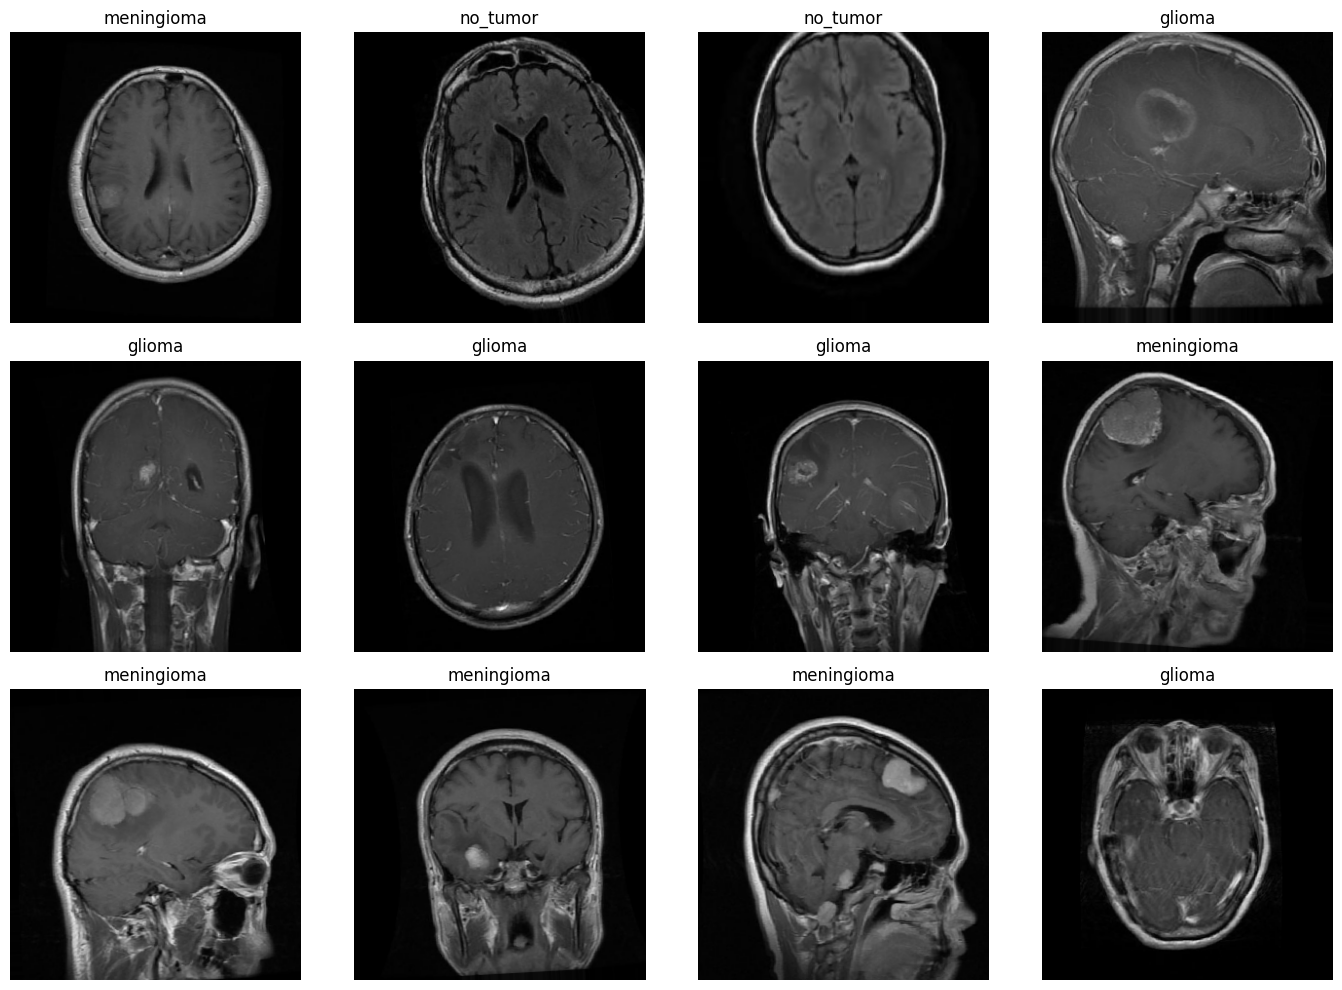

In [3]:
# ============================================================
# VISUALIZE MRI IMAGES
# ============================================================

images, labels = next(train_generator)

plt.figure(figsize=(14,10))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(images[i])

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()

plt.savefig("augmented_samples.png")

plt.show()

In [4]:
# ============================================================
# CBAM ATTENTION MODULE
# ============================================================

class CBAM(tf.keras.layers.Layer):

    def __init__(self, reduction_ratio=16):

        super(CBAM, self).__init__()

        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):

        channels = input_shape[-1]

        self.avg_pool = layers.GlobalAveragePooling2D()

        self.max_pool = layers.GlobalMaxPooling2D()

        self.dense1 = layers.Dense(

            channels // self.reduction_ratio,

            activation='relu'
        )

        self.dense2 = layers.Dense(

            channels,

            activation='sigmoid'
        )

        self.conv = layers.Conv2D(

            filters=1,

            kernel_size=7,

            padding='same',

            activation='sigmoid'
        )

    def call(self, inputs):

        # =========================
        # CHANNEL ATTENTION
        # =========================

        avg = self.avg_pool(inputs)

        maxp = self.max_pool(inputs)

        avg = self.dense2(self.dense1(avg))

        maxp = self.dense2(self.dense1(maxp))

        attention = avg + maxp

        attention = tf.expand_dims(
            tf.expand_dims(attention,1),1
        )

        x = inputs * attention

        # =========================
        # SPATIAL ATTENTION
        # =========================

        avg_pool = tf.reduce_mean(
            x,
            axis=-1,
            keepdims=True
        )

        max_pool = tf.reduce_max(
            x,
            axis=-1,
            keepdims=True
        )

        concat = tf.concat(
            [avg_pool, max_pool],
            axis=-1
        )

        spatial_attention = self.conv(concat)

        return x * spatial_attention

In [5]:
# ============================================================
# BUILD MODEL
# ============================================================

inputs = tf.keras.Input(

    shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

# ============================================================
# INCEPTIONV3 BACKBONE
# ============================================================

base_model = InceptionV3(

    include_top=False,

    weights='imagenet',

    input_tensor=inputs
)

# Freeze backbone
base_model.trainable = False

# ============================================================
# FEATURE EXTRACTION
# ============================================================

x = base_model.output

# ============================================================
# APPLY CBAM
# ============================================================

x = CBAM()(x)

# ============================================================
# GLOBAL POOLING
# ============================================================

x = layers.GlobalAveragePooling2D()(x)

# ============================================================
# FULLY CONNECTED LAYERS
# ============================================================

x = layers.Dense(

    1024,

    activation='relu',

    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(

    512,

    activation='relu'
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(

    256,

    activation='relu'
)(x)

x = layers.Dropout(0.2)(x)

# ============================================================
# OUTPUT LAYER
# ============================================================

outputs = layers.Dense(

    4,

    activation='softmax'
)(x)

# ============================================================
# FINAL MODEL
# ============================================================

model = tf.keras.Model(inputs, outputs)

model.summary()

I0000 00:00:1779994835.381255    5827 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 25,090,823 (95.71 MB)

 Trainable params: 3,284,967 (12.53 MB)

 Non-trainable params: 21,805,856 (83.18 MB)

In [6]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [7]:
# ============================================================
# CALLBACKS
# ============================================================

callbacks = [

    EarlyStopping(

        monitor='val_accuracy',

        patience=10,

        restore_best_weights=True,

        mode='max'
    ),

    ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        min_lr=1e-7,

        verbose=1
    ),

    ModelCheckpoint(

        filepath=f"{MODEL_DIR}/best_model.keras",

        monitor='val_accuracy',

        save_best_only=True,

        mode='max'
    )
]

In [8]:
# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(

    train_generator,

    validation_data=test_generator,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/30


2026-05-28 19:01:09.371982: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 51495936 bytes after encountering the first element of size 51495936 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1779994869.415033    6005 service.cc:148] XLA service 0x772434073ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779994869.415121    6005 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-05-28 19:01:09.653008: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779994870.956519    6005 cuda_dnn.cc:529] Loaded cuDNN version 91900
2026-05-28 19:01:12.080791: I external/local_xla/xla/stream_executor/cuda/cuda_a

 69/105 ━━━━━━━━━━━━━━━━━━━━ 32s 893ms/step - accuracy: 0.4986 - loss: 1.4822

2026-05-28 19:02:37.131174: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9031_0', 8 bytes spill stores, 8 bytes spill loads

2026-05-28 19:02:39.912723: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:378] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 988ms/step - accuracy: 0.5512 - loss: 1.3347

2026-05-28 19:03:32.859515: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2591', 224 bytes spill stores, 224 bytes spill loads

2026-05-28 19:03:33.094431: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2591_0', 8 bytes spill stores, 8 bytes spill loads

2026-05-28 19:03:33.131199: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2591_0', 672 bytes spill stores, 1036 bytes spill loads



105/105 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.6736 - loss: 0.9928 - val_accuracy: 0.5210 - val_loss: 1.2911 - learning_rate: 1.0000e-04
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 102s 965ms/step - accuracy: 0.8266 - loss: 0.5879 - val_accuracy: 0.7410 - val_loss: 1.0127 - learning_rate: 1.0000e-04
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 99s 934ms/step - accuracy: 0.8582 - loss: 0.5046 - val_accuracy: 0.8220 - val_loss: 0.7179 - learning_rate: 1.0000e-04
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 85s 813ms/step - accuracy: 0.8758 - loss: 0.4698 - val_accuracy: 0.8470 - val_loss: 0.5288 - learning_rate: 1.0000e-04
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 88s 838ms/step - accuracy: 0.8858 - loss: 0.4386 - val_accuracy: 0.8860 - val_loss: 0.4355 - learning_rate: 1.0000e-04
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 89s 848ms/step - accuracy: 0.8956 - loss: 0.4091 - val_accuracy: 0.8680 - val_loss: 0.4488 - learning_rate: 1.0000e-04
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 85s 806ms/step - a

MODEL SAVED SUCCESSFULLY ✅


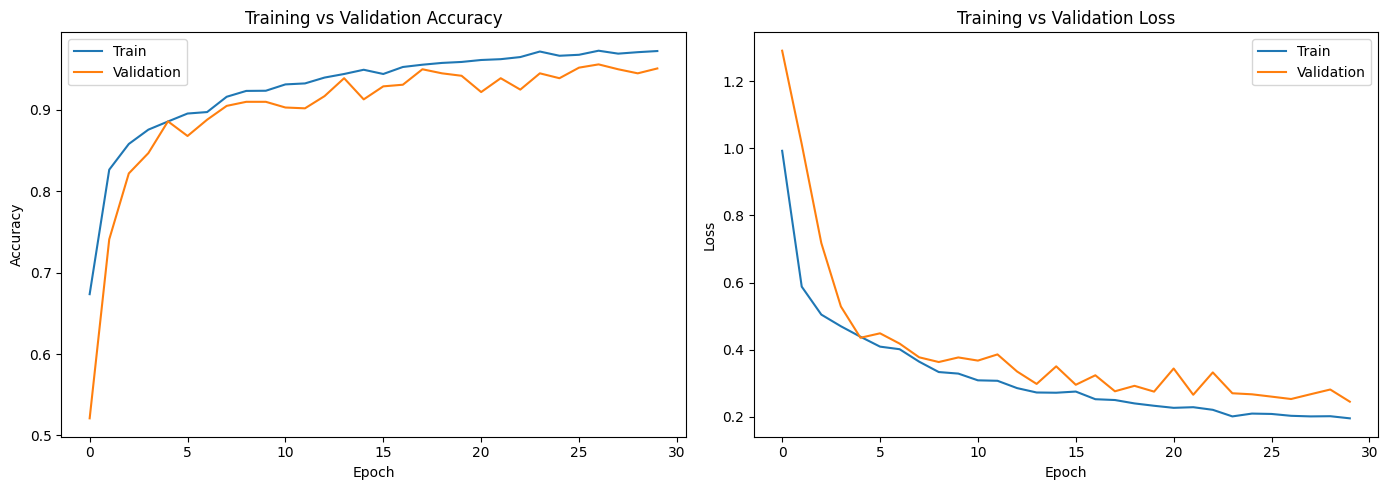

21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 571ms/step


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.95      0.94      0.94       254
  meningioma       0.95      0.91      0.93       306
    no_tumor       0.96      1.00      0.98       140
   pituitary       0.96      1.00      0.98       300

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



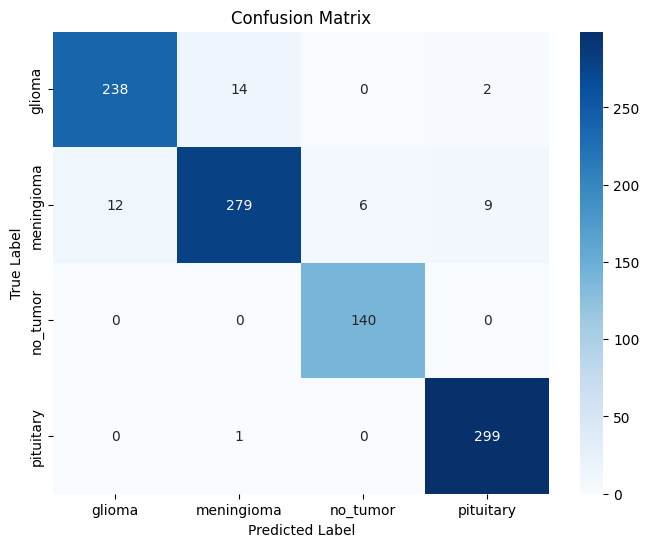

In [9]:

# ============================================================
# IMPORT EVALUATION LIBRARIES
# ============================================================

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns


# ============================================================
# SAVE FINAL MODEL
# ============================================================

MODEL_SAVE_PATH = "/home/mahir/DL_PROJECTS/brain_tumor_project/MODEL/final_model_1.keras"

model.save(MODEL_SAVE_PATH)

print("MODEL SAVED SUCCESSFULLY ✅")


# ============================================================
# PLOT TRAINING CURVES
# ============================================================

plt.figure(figsize=(14, 5))


# ------------------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])


# ------------------------------------------------------------
# LOSS CURVE
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])


plt.tight_layout()

plt.show()


# ============================================================
# MODEL PREDICTIONS
# ============================================================

predictions = model.predict(test_generator)


# Predicted labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()


OUTPUT DIRECTORY CREATED ✅


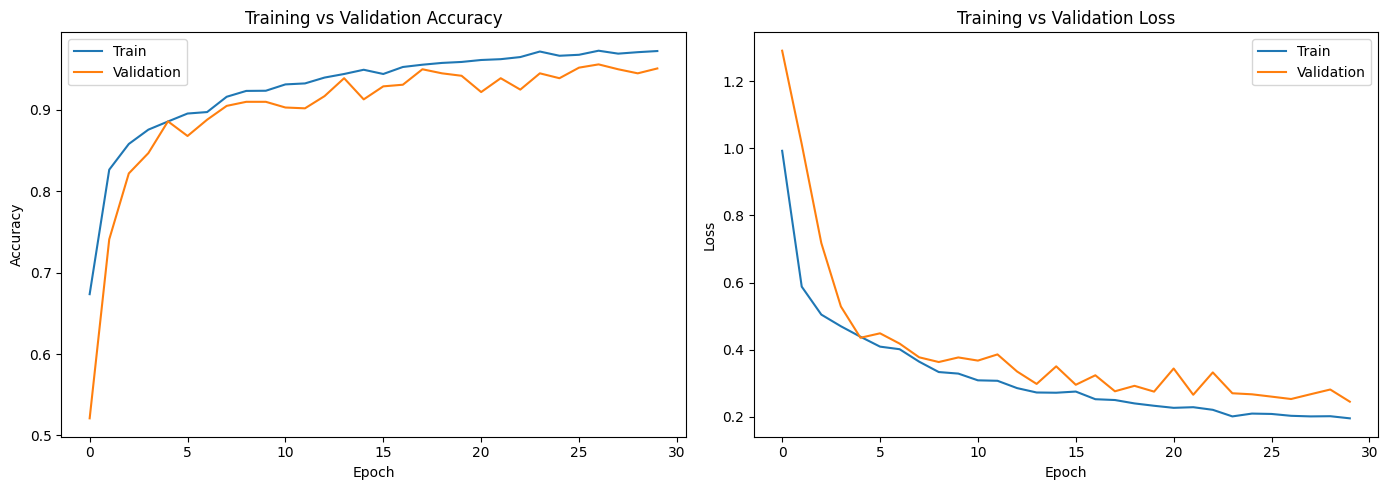

Training History Saved ✅


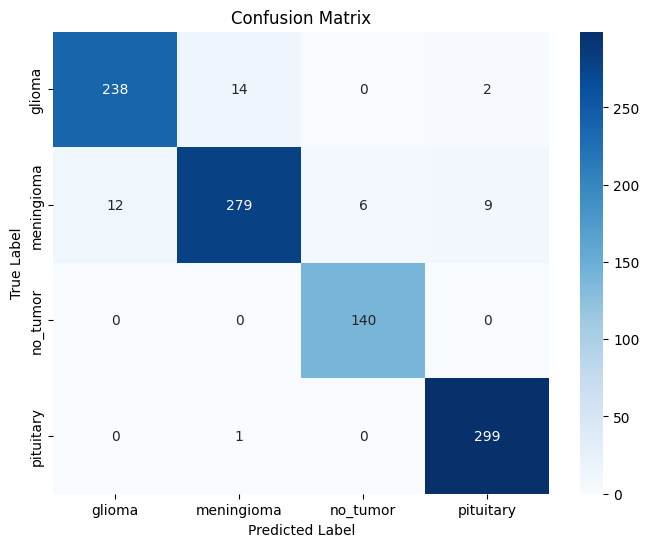

Confusion Matrix Saved ✅
Classification Report Saved ✅
Metrics CSV Saved ✅


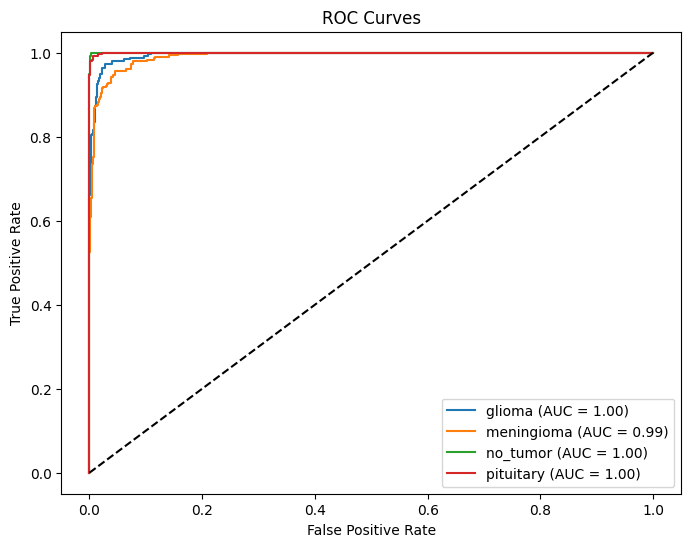

ROC Curves Saved ✅


2026-05-28 20:42:04.610606: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2534_0', 152 bytes spill stores, 400 bytes spill loads

2026-05-28 20:42:04.662645: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2534_0', 112 bytes spill stores, 224 bytes spill loads

2026-05-28 20:42:05.052188: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2534', 220 bytes spill stores, 576 bytes spill loads



1/2 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step

2026-05-28 20:42:24.486374: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2534_0', 204 bytes spill stores, 204 bytes spill loads



2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 15s/step


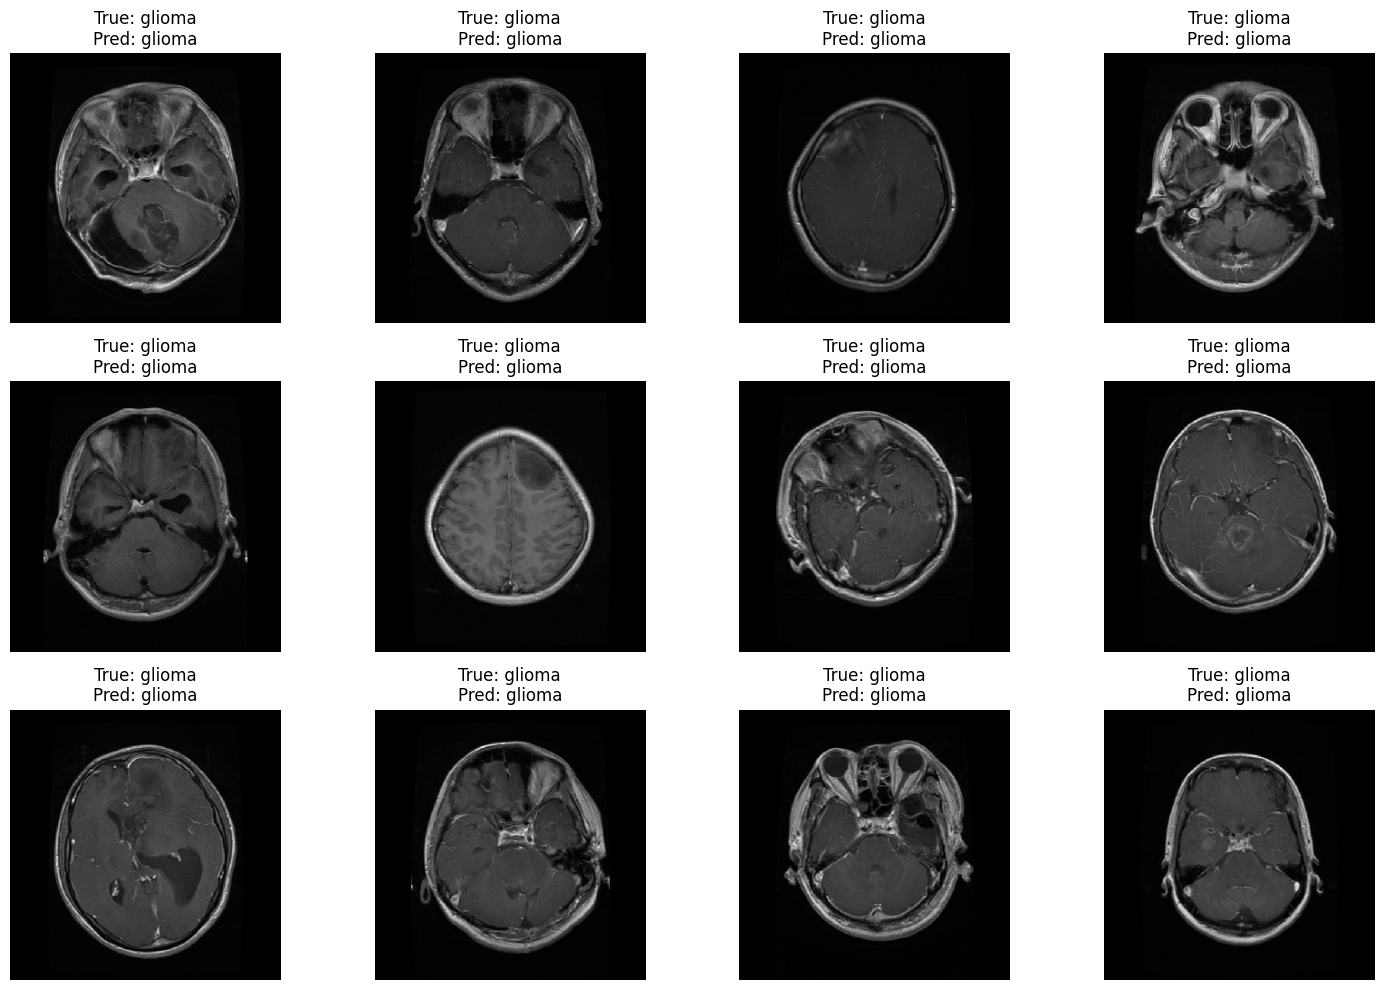

Sample Predictions Saved ✅

ALL OUTPUT FILES SAVED SUCCESSFULLY ✅

OUTPUT DIRECTORY: /home/mahir/DL_PROJECTS/brain_tumor_project/OUTPUT

Saved Files:
• training_history.png
• confusion_matrix.png
• classification_report.txt
• metrics.csv
• roc_curves.png
• sample_predictions.png


In [10]:
# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "/home/mahir/DL_PROJECTS/brain_tumor_project/OUTPUT"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("OUTPUT DIRECTORY CREATED ✅")


# ============================================================
# SAVE TRAINING HISTORY GRAPH
# ============================================================

plt.figure(figsize=(14,5))

# -------------------------
# ACCURACY CURVE
# -------------------------

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])


# -------------------------
# LOSS CURVE
# -------------------------

plt.subplot(1,2,2)

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.tight_layout()

plt.savefig(

    f"{OUTPUT_DIR}/training_history.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print("Training History Saved ✅")


# ============================================================
# SAVE CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.savefig(

    f"{OUTPUT_DIR}/confusion_matrix.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print("Confusion Matrix Saved ✅")


# ============================================================
# SAVE CLASSIFICATION REPORT
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    target_names=class_names
)

with open(

    f"{OUTPUT_DIR}/classification_report.txt",

    "w"
) as f:

    f.write(report)

print("Classification Report Saved ✅")


# ============================================================
# SAVE METRICS CSV
# ============================================================

metrics_df = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"
    ],

    "Value": [

        accuracy_score(y_true, y_pred),

        precision_score(
            y_true,
            y_pred,
            average='weighted'
        ),

        recall_score(
            y_true,
            y_pred,
            average='weighted'
        ),

        f1_score(
            y_true,
            y_pred,
            average='weighted'
        )
    ]
})

metrics_df.to_csv(

    f"{OUTPUT_DIR}/metrics.csv",

    index=False
)

print("Metrics CSV Saved ✅")


# ============================================================
# ROC CURVE
# ============================================================

y_true_bin = label_binarize(

    y_true,

    classes=[0,1,2,3]
)

plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(

        y_true_bin[:, i],

        predictions[:, i]
    )

    auc_score = roc_auc_score(

        y_true_bin[:, i],

        predictions[:, i]
    )

    plt.plot(

        fpr,

        tpr,

        label=f"{class_names[i]} (AUC = {auc_score:.2f})"
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.savefig(

    f"{OUTPUT_DIR}/roc_curves.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print("ROC Curves Saved ✅")


# ============================================================
# SAVE SAMPLE PREDICTIONS
# ============================================================

images, labels = next(test_generator)

preds = model.predict(images)

plt.figure(figsize=(15,10))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(images[i])

    true_label = class_names[np.argmax(labels[i])]

    pred_label = class_names[np.argmax(preds[i])]

    plt.title(

        f"True: {true_label}\nPred: {pred_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(

    f"{OUTPUT_DIR}/sample_predictions.png",

    dpi=300,

    bbox_inches='tight'
)

plt.show()

print("Sample Predictions Saved ✅")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*60)

print("ALL OUTPUT FILES SAVED SUCCESSFULLY ✅")

print("="*60)

print(f"\nOUTPUT DIRECTORY: {OUTPUT_DIR}")

print("\nSaved Files:")

print("• training_history.png")

print("• confusion_matrix.png")

print("• classification_report.txt")

print("• metrics.csv")

print("• roc_curves.png")

print("• sample_predictions.png")

